In [1]:
# import
from hsflfm.config import home_directory
from hsflfm.util import (
    load_graph_images,
    load_dictionary,
    generate_A_matrix,
    MetadataManager,
)
from hsflfm.calibration import (
    CalibrationInfoManager,
    SystemVertexParser,
    SystemCalibrator,
    FLF_System,
)

import os
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

import matplotlib

Step 1: Parse Vertices

In [2]:
# calibration filename can be manually specified or pulled from stored metadata
# the specified specimen can be any specimen that was filmed on the under these calibration conditions
#specimen = "20240506_OB_6"
#specimen = "20260313_A"
# specimen = "20260317_B"
specimen = "20260511_B"

mm = MetadataManager(specimen)

calibration_filename = mm.calibration_filename

calibration_folder = mm.calibration_folder


info_manager = CalibrationInfoManager(calibration_filename)
print(calibration_folder)

C:/Users/abhin/Box/Vaduri_Abhinav Jumping Shells/Collected_Disk_Videos/20260511_B/calibration_images


In [3]:
print(info_manager.filename)

C:/Users/abhin/Box/Vaduri_Abhinav Jumping Shells/Collected_Disk_Videos/20260511_B/calibration_images/calibration_information


In [4]:
# known information
#info_manager.vertex_spacing_m = 500e-6  # spacing between vertices on the graph target
info_manager.vertex_spacing_m = 1e-3 #
info_manager.pixel_size = 52e-6  # pixel size in meters of the camera

info_manager.save_all_info()

In [5]:
# give the manager enough information to find the graph images
# this may need to be changed if different naming conventions were used
# the dictionary just needs to contain a substring that is unique to the specific plane image

plane_names = np.sort([i for i in os.listdir(calibration_folder) if "tiff" in i])
name_dict = {}
for i, name in enumerate(plane_names):
    name_dict[i] = name
info_manager.plane_names = name_dict

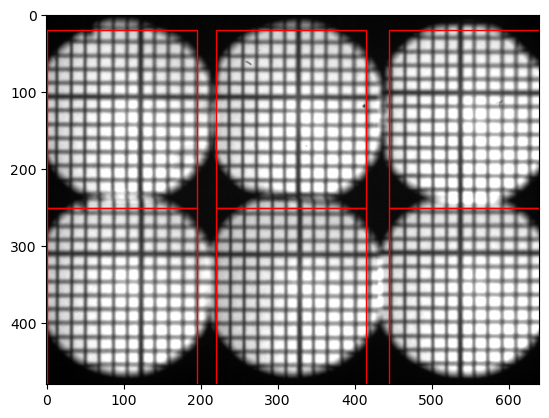

In [6]:
# load one image to identify where images should be cropped
# Right now, crops are expected to be the same size for all views

#Indexing
#[ 0 | 2 | 4 ]
#[ 1 | 3 | 5 ]

# standard crops for 3 camera system for ants
# crop_indices = {
#     0: [230, 480, 0, 200],
#     1: [230, 480, 440, 640],
#     2: [0, 250, 220, 420],
# }

# standard crops for 6 camera system for Ants
# crop_indices = {
#     0: [20, 250, 0, 210],
#     1: [250, 480, 0, 210],
#     2: [20, 250, 220, 430],
#     3: [250, 480, 220, 430],
#     4: [20, 250, 430, 640],
#     5: [250, 480, 430, 640]
# }

# Jumping Disk Crop indices
crop_indices = {
    0: [20, 250, 0, 195],
    1: [250, 480, 0, 195],
    2: [20, 250, 220, 415],
    3: [250, 480, 220, 415],
    4: [20, 250, 445, 640],
    5: [250, 480, 445, 640]
}

# crop_indices = {
#     0: [10, 240,10, 220],
#     1: [240, 470, 0, 210],
#     2: [10, 240, 240, 450],
#     3: [240, 470, 220, 430],
#     4: [10, 240, 460, 640],
#     5: [240, 470, 430, 640]
# }

# this could be done with any image, including of an ant
image_filename = calibration_folder + "/" + plane_names[0]
raw_image = Image.open(image_filename)
plt.imshow(raw_image)
ax = plt.gca()
for c in crop_indices.values():
    rect = Rectangle((c[2], c[0]), c[3] - c[2], c[1] - c[0], fill=False, color="red")
    ax.add_artist(rect)

In [7]:
info_manager.crop_indices = crop_indices
info_manager.save_all_info()

In [8]:
# load all the images
all_images = load_graph_images(
    folder=calibration_folder, calibration_filename=calibration_filename
)

In [9]:
# Check Loaded image names
for i, name in enumerate(plane_names):
    print(f"Plane {i}: {name}")

Plane 0: 20260511_00_0.tiff
Plane 1: 20260511_02_0.tiff
Plane 2: 20260511_04_0.tiff
Plane 3: 20260511_06_0.tiff
Plane 4: 20260511_08_0.tiff
Plane 5: 20260511_10_0.tiff
Plane 6: 20260511_12_0.tiff
Plane 7: 20260511_14_0.tiff
Plane 8: 20260511_16_0.tiff
Plane 9: 20260511_18_0.tiff
Plane 10: 20260511_20_0.tiff


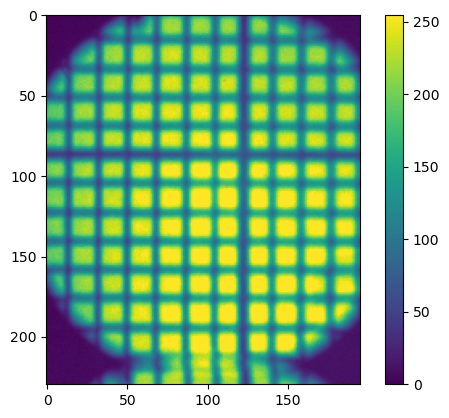

In [10]:
# view one image to get the expected spacing between lines
plt.figure()
plt.imshow(all_images[0][0])
plt.colorbar()

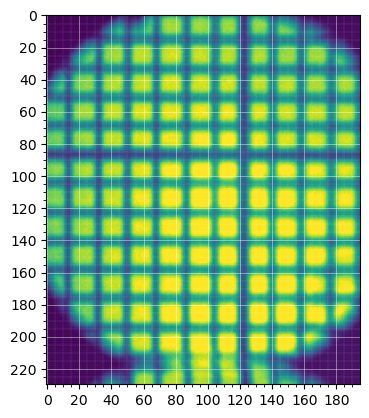

In [11]:
plt.imshow(all_images[0][0])
img = all_images[0][0]
# Major ticks (labeled every 20 pixels)
plt.xticks(np.arange(0, img.shape[1], 20))
plt.yticks(np.arange(0, img.shape[0], 20))

# Minor ticks (grid every 5 pixels, no labels)
plt.gca().set_xticks(np.arange(0, img.shape[1], 5), minor=True)
plt.gca().set_yticks(np.arange(0, img.shape[0], 5), minor=True)

# Grid styling
plt.grid(which='major', color='white', linestyle='-', linewidth=0.5, alpha=0.6)
plt.grid(which='minor', color='white', linestyle='--', linewidth=0.3, alpha=0.3)

plt.gca().set_aspect('equal')
plt.show()

In [12]:
# Estimate the pixel spacing between lines of the above grid, this wil be used later

#expected_spacing = 160 - 135

expected_spacing = 20 #Roughly for grid paper

In [13]:
# Initialize the vertex parsing system for calibration.
#
# This object:
# - Loads calibration metadata (crop regions, saved parameters)
# - Sets the expected grid spacing (in pixels), which is used to:
#     1. group detected Hough lines
#     2. define refinement window sizes (LSF/ESF)
#     3. generate default threshold parameters
# - Stores all calibration images across cameras and Z-planes

parser = SystemVertexParser(
    calibration_filename,
    expected_vertex_spacing=expected_spacing,
    all_images=all_images,
)

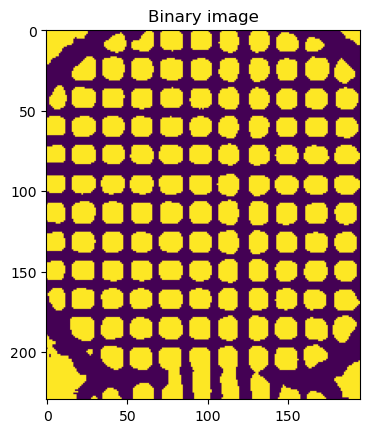

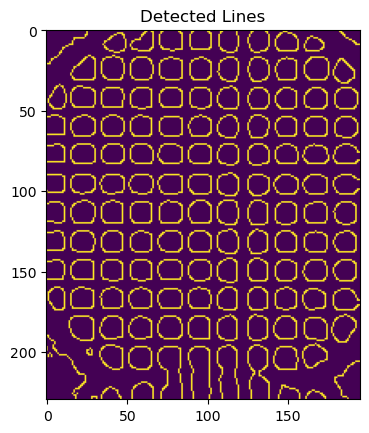

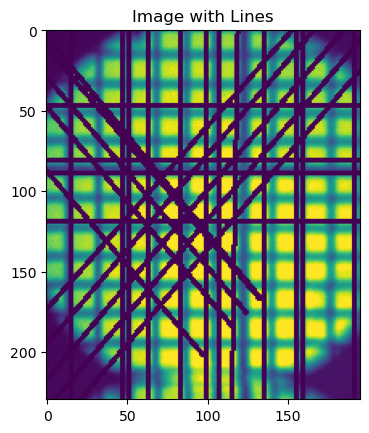

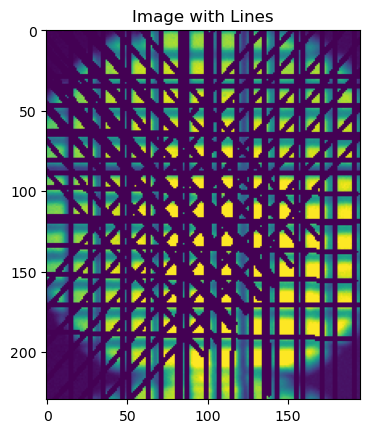

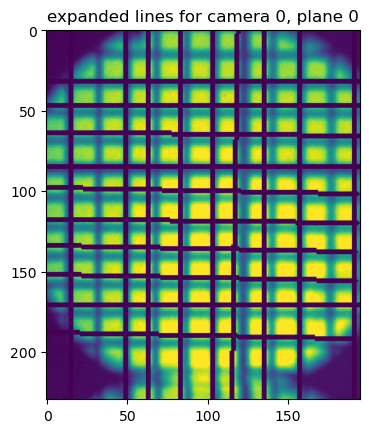

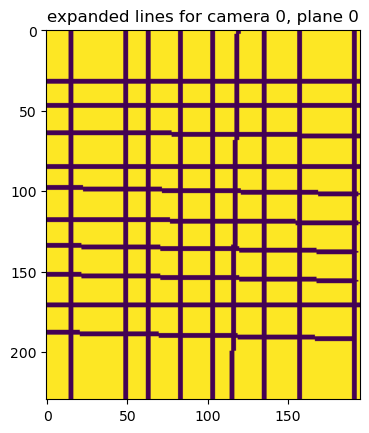

In [ ]:
# use this cell to adjust settings for finding the lines in the images
# Settings used here for a test image will automatically be used for remaining images
# if this is used to adjust settings for multiple images, it becomes slightly complicated
# which settings are used for which images. This eventually needs to be fixed or documented better.


threshold_values = {

    #-------------------------------------------------------------------------
    # Adapative Thresholding(Binarization step)
    # 
    # cv2.adaptiveThreshold uses a local window to determine whether each pixel
    # is foreground(a grid line) or background, converting graph images to 
    # binary images. This is critical because illumination is not uniform across 
    # FOV with this lens array
    #
    # PARAMETER: Size of the local window(Should be an odd number)
    #  - Should approximately match the expected spacing
    #
    # Example: For a 1mm(~20px spacing), 21 works well
    #-------------------------------------------------------------------------
    "adaptive_threshold_range": 21,


    # ------------------------------------------------------------------------
    # Median blur(noise suppression step)
    #
    # Applied AFTER thresholding, Removes small speckle noise identifies edges.
    # - used in cv2.medianBlur to filter the binary image
    #
    # PARAMETER:
    # Kernel size (must be odd, >=1)
    #
    # If too small: noise remains, creating false edges in Canny
    # If too large: erodes thin grid lines, weakens Hough detection
    #
    # Typical values:
    #   1–3 for high-quality images
    #   3–5 if noisy
    # -------------------------------------------------------------------------
    "blur_range": 3,


    # ------------------------------------------------------------------------
    # Canny edge detection thresholds: Converts binary image to edge map
    #
    # Uses hysteresis:
    #   - strong edges (above edge_thresh2) are always kept
    #   - weak edges (between thresh1 and thresh2) are kept
    #     only if connected to strong edges
    #
    # PARAMETER:
    # edge_thresh1 = lower threshold
    # edge_thresh2 = upper threshold
    #
    # If thresholds too high:
    #    missing edges, missing grid lines
    #
    # If thresholds too low:
    #   noisy edges, false Hough lines
    #
    # Consult cv2 documentation for further use
    # ------------------------------------------------------------------------
    "edge_thresh1": 100,
    "edge_thresh2": 140,

    # ------------------------------------------------------------------------
    # Canny gradient aperture size: Controls Sobel filter size used for gradient computation
    #
    # Smaller: sharper edges, more sensitive to noise
    # Larger: smoother edges, less noise, but less precise
    #
    # ------------------------------------------------------------------------
    "edge_aperture": 5,

    # --------------------------------------------------------
    # Hough transform threshold (line detection)
    # - Determines how many edge pixels must lie on a line
    #   for it to be considered valid.
    #
    # Calculated as:
    #   threshold = line_thresh_per_pixel × image_size
    #   So this parameter is a normalized fraction.
    #
    # If too high: broken / curved lines are missed
    # If too low: spurious lines detected (noise)
    # --------------------------------------------------------
    "line_thresh_per_pixel": 0.55,

}

# Choose a camera number and plane combination below to see how your paramters perform
camera_number = 0

plane_number = 0

parser.find_lines(
    camera_number,
    plane_number,
    show=True,
    threshold_values=threshold_values,
    show_process=True,
)

In [15]:
# ------------------------------------------------------------
# Detect grid lines in ALL calibration images
#
# This applies threshold parameters to every
# camera and plane in the dataset.
# Only images without existing line detections are processed.
#
# show=False:  suppress plotting (faster)
# max_display: safety limit on number of images processed
#
# After this step:
# - Horizontal and vertical grid lines are detected
# - Results are stored in the calibration file
# ------------------------------------------------------------

parser.find_all_remaining_lines(show=False, max_display=1000)
parser.save_all_parameters()

Approx points: 90
Final vertices: 80


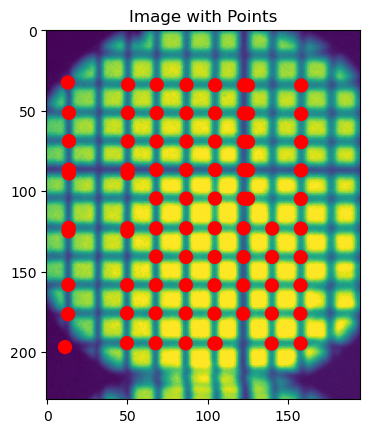

In [16]:
# ------------------------------------------------------------
# Test vertex extraction on a single camera / plane
#
# This step:
# - Computes intersections between detected grid lines
# - Refines each intersection using subpixel edge fitting (ESF/LSF)
# - Displays the resulting vertex locations overlaid on the image
#
# This is a diagnostic step to verify that:
# 1. Lines are correctly detected
# 2. Grid intersections are complete and evenly spaced
# 3. No rows/columns are missing
#
# If errors occur (e.g. NaNs), try a different camera/plane
# to identify problematic images before batch processing.
# ------------------------------------------------------------

parser.find_vertices(camera_number=0, plane_number=0, show=True)

In [18]:
# This can be uncommented to help figure out why a point was not found
# near a given location

# parser.debug_missing_point(2, 5, (140, 80))

In [17]:
# ------------------------------------------------------------
# Extract vertices from all calibration images
#
# This step:
# - Uses previously detected grid lines
# - Computes intersections (approximate grid points)
# - Refines each point using subpixel edge fitting (ESF/LSF)
#
# The result is a full set of vertex coordinates across
# all cameras and all Z planes
#
# These vertices form the dataset used for calibration fitting.
#
# remove_nan_points():
# - Removes any failed vertex detections (NaNs)
# - Prevents errors during least-squares calibration fitting
#
# save_all_parameters():
# - Saves all detected vertices and parameters to the calibration file
# ------------------------------------------------------------
parser.find_all_remaining_vertices(show=False, max_display=200)
parser.remove_nan_points()
parser.save_all_parameters()

Approx points: 81
Final vertices: 75
Approx points: 90
Final vertices: 90
Approx points: 90
Final vertices: 89
Approx points: 80
Final vertices: 78
Approx points: 80
Final vertices: 80
Approx points: 100
Final vertices: 88
Approx points: 72
Final vertices: 70
Approx points: 90
Final vertices: 87
Approx points: 81
Final vertices: 79
Approx points: 100
Final vertices: 95
Approx points: 100
Final vertices: 99
Approx points: 100
Final vertices: 90
Approx points: 72
Final vertices: 64
Approx points: 90
Final vertices: 88
Approx points: 90
Final vertices: 78
Approx points: 90
Final vertices: 90
Approx points: 88
Final vertices: 84
Approx points: 80
Final vertices: 76
Approx points: 99
Final vertices: 87
Approx points: 90
Final vertices: 88
Approx points: 88
Final vertices: 76
Approx points: 90
Final vertices: 81
Approx points: 100
Final vertices: 85
Approx points: 100
Final vertices: 89
Approx points: 99
Final vertices: 88
Approx points: 99
Final vertices: 94
Approx points: 90
Final vertices

Step 2: Remove extraneous vertices

While this step can be improved in future versions, right now extraneous vertices must be manually removed, or they will impact the calibration results. This can be done by running ``remove_vertices.py`` (first open the file and adjust necessary settings, particularly the file names). 

Step 3: identify approximate alignment points between images

This step can likely be automated in future versions of the code, but right now the user must manually select approximate alignment points between the images. This can be done by finding a feature visible in all images, then running ``select_alignment_points.py`` to click on that point in all the images. 

Step 4: Fit calibration coefficients

In this portion, the identified graph vertices are used to perform inter- and intr-camera calibration

In [21]:
# this can be uncommented to display interactive plots
# %matplotlib notebook

In [22]:
reference_camera = 2

In [23]:
# select reference plane based on how many vertices were identified in each plane
# the first number gives the total number of vertices identified in a given plane
# between all images
# and the second number is the number of identified vertices in the image with the
# least identified vertices.
# both of these numbers should be reasonably large in the chosen reference plane
vertices = load_dictionary(calibration_filename)["all_vertices"]

for plane_num, values in vertices.items():
    plane_points = 0
    min_points = np.inf
    for cam, points in values.items():
        plane_points = plane_points + len(points)
        min_points = min(min_points, len(points))
    print(
        plane_num,
        "total points:",
        plane_points,
        ", mininum points in an image:",
        min_points,
    )

0 total points: 464 , mininum points in an image: 56
5 total points: 614 , mininum points in an image: 95
1 total points: 473 , mininum points in an image: 56
2 total points: 535 , mininum points in an image: 72
3 total points: 553 , mininum points in an image: 80
4 total points: 629 , mininum points in an image: 92
6 total points: 646 , mininum points in an image: 99
7 total points: 661 , mininum points in an image: 107
8 total points: 660 , mininum points in an image: 98
9 total points: 685 , mininum points in an image: 107
10 total points: 645 , mininum points in an image: 97


In [24]:
reference_plane = 5

In [25]:
#plane_separation_mm = 0.381  # this is the step size most often used between planes
plane_separation_mm = 1  # 2 full turns of the of the MAZ-40-10 stage
calibrator = SystemCalibrator(
    calibration_filename=calibration_filename,
    reference_plane=reference_plane,
    reference_camera=reference_camera,
    plane_separation_mm=plane_separation_mm,
    ref_plane_image_folder=None,
    useable_plane_numbers=None,  # if None, this will use all planes
)

KeyError: 2

C:\Users\abhin\HighSpeedFLFM\hsflfm\util\polynomial_fit_functions.py:29: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coeff, _, _, _ = np.linalg.lstsq(A, Z)


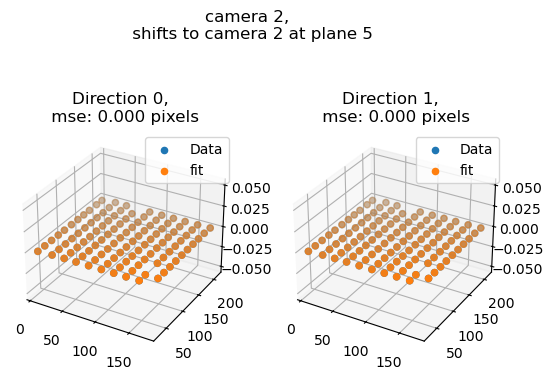

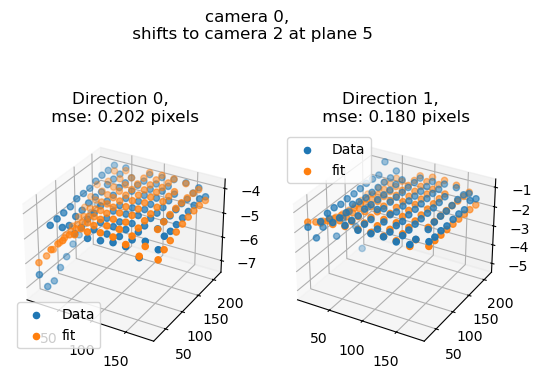

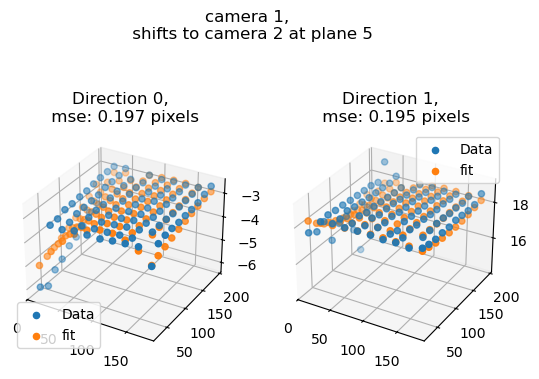

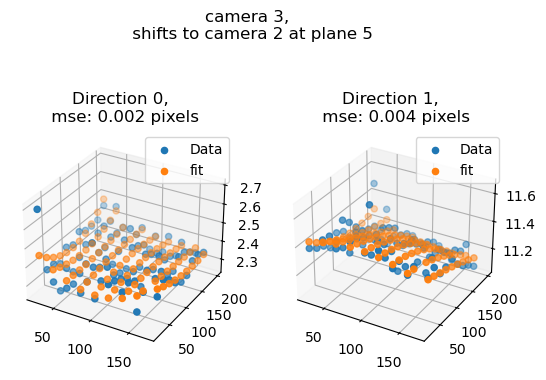

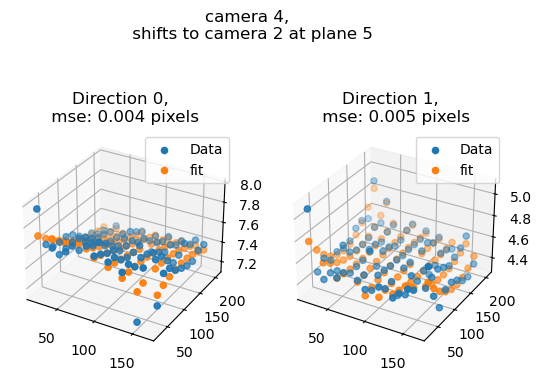

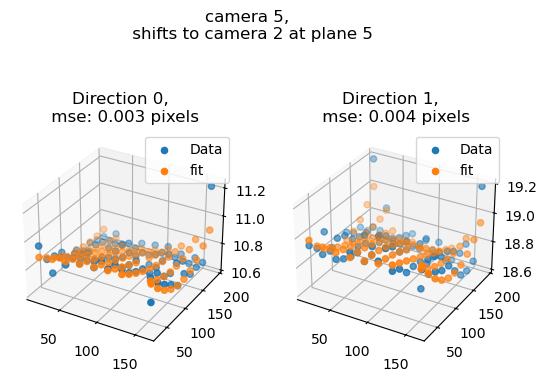

: 

: 

: 

: 

In [ ]:
calibrator.run_inter_camera_calibration(show=True, order=2)

c:\Users\abhin\anaconda3\envs\hsflfm_cpu\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\abhin\anaconda3\envs\hsflfm_cpu\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


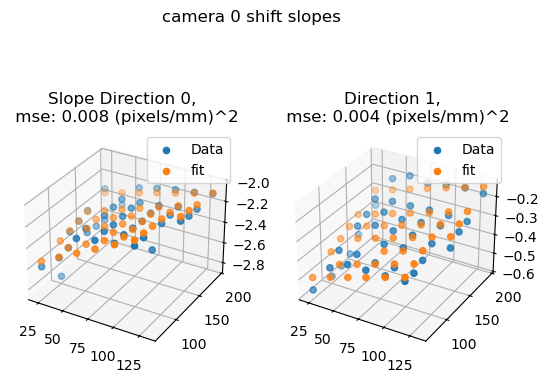

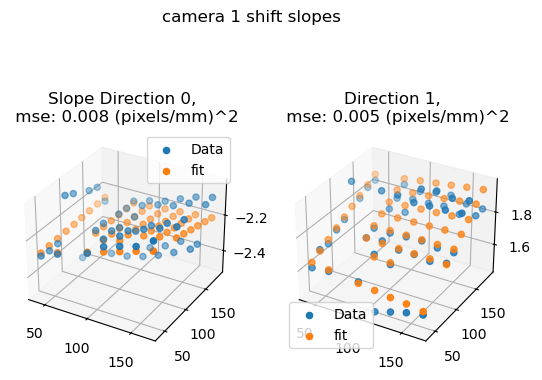

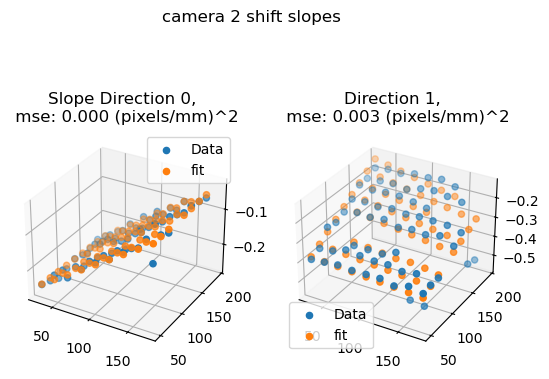

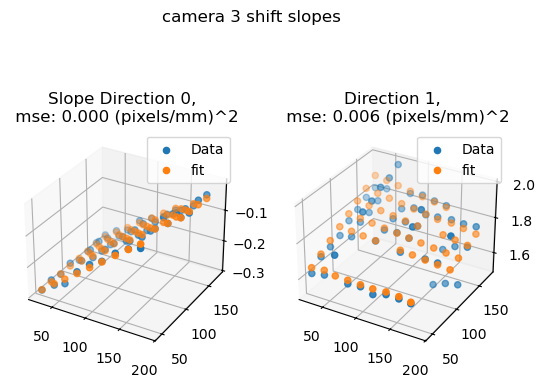

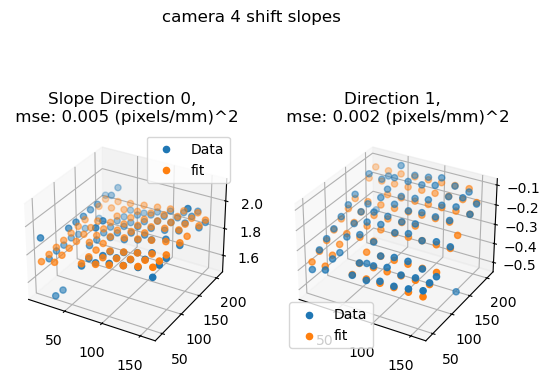

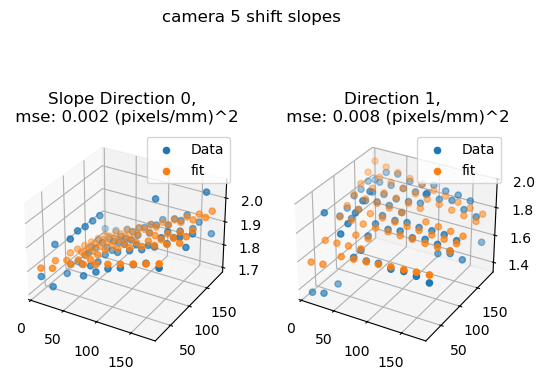

: 

: 

: 

: 

In [ ]:
calibrator.run_slope_calibration(show=True, order=1)

In [ ]:
%debug



ERROR:root:No traceback has been produced, nothing to debug.


: 

: 

: 

: 

Step 5: check if results look reasonable

In [ ]:
system = FLF_System(calibration_filename)
all_camera_vertices_matrices = calibrator.all_camera_vertices_matrices

: 

: 

: 

: 

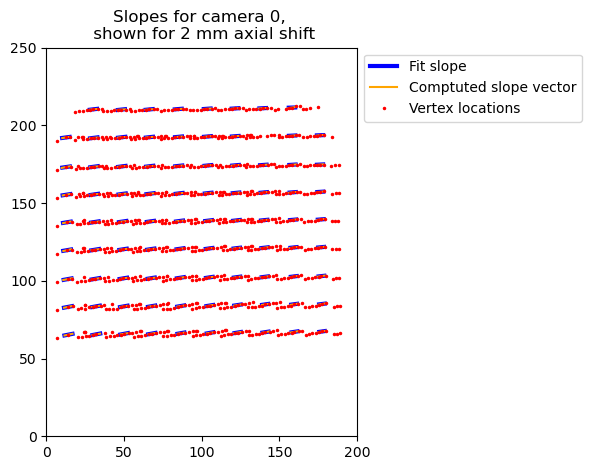

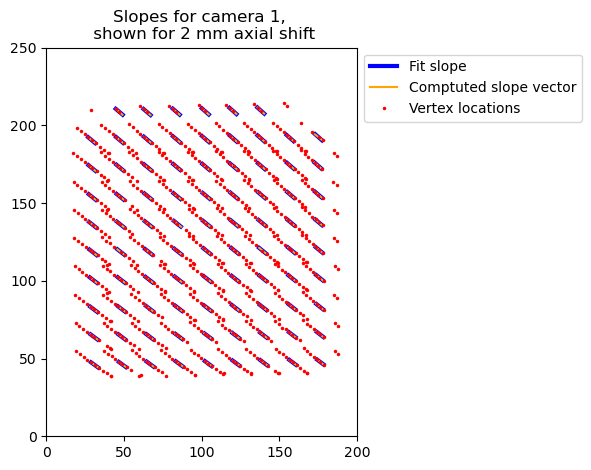

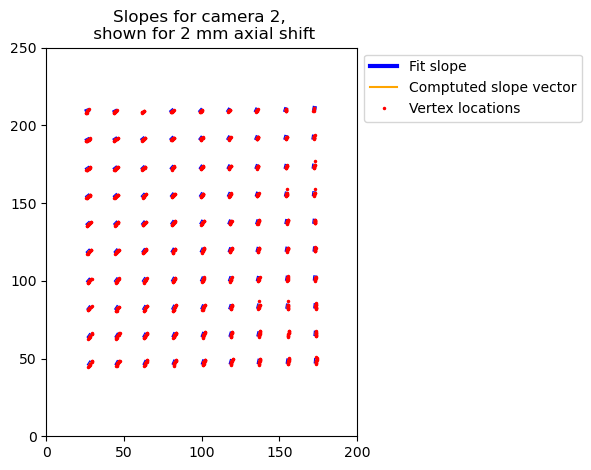

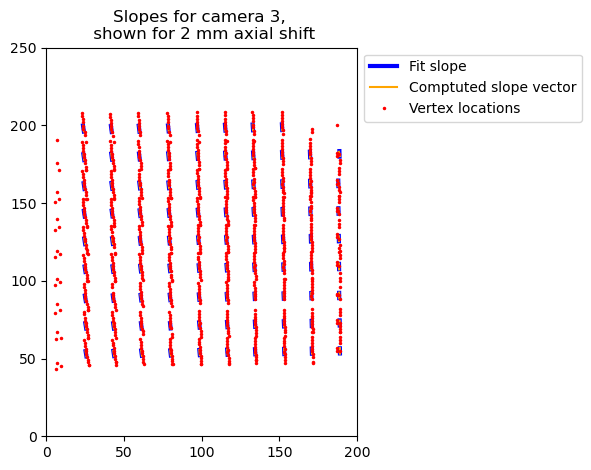

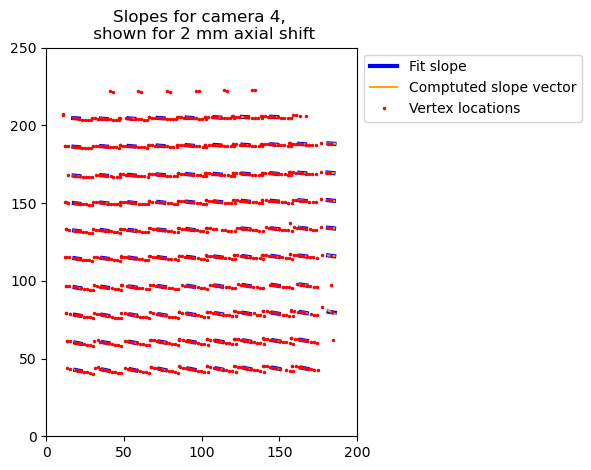

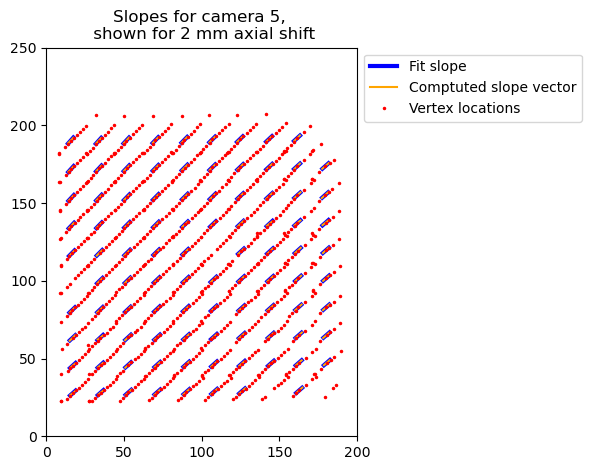

: 

: 

: 

: 

In [ ]:
def make_comparison_plot(camera_number, vector_length_mm=None):
    slope0, slope1 = calibrator.get_slopes_from_vertices_matrices(camera_number)
    vertices_matrices = all_camera_vertices_matrices[camera_number]

    plt.figure()
    matrix_shape = vertices_matrices.shape[1:3]
    first = True
    for i, j in np.ndindex(matrix_shape):
        if first:
            label1 = "Comptuted slope vector"
            label2 = "Fit slope"
            label3 = "Vertex locations"
        else:
            label1 = None
            label2 = None
            label3 = None

        X = vertices_matrices[:, i, j, 0]
        Y = vertices_matrices[:, i, j, 1]

        if not np.isnan(slope0[i, j]):
            if vector_length_mm is None:
                start_plane_mm = (
                    np.where(~np.isnan(X))[0][0] - system.reference_plane
                ) * plane_separation_mm
                end_plane_mm = (
                    np.where(~np.isnan(X))[0][-1] - system.reference_plane
                ) * plane_separation_mm
            else:
                start_plane_mm = -vector_length_mm / 2
                end_plane_mm = vector_length_mm / 2

            x = vertices_matrices[system.reference_plane, i, j, 0]
            y = vertices_matrices[system.reference_plane, i, j, 1]

            # plot the slope vector that was fit to that point
            coeff0, coeff1 = system._get_slope_coeffs(camera_number)
            slope_matrix = generate_A_matrix(system.slope_order, [x], [y])
            v1 = np.matmul(slope_matrix, coeff0)[0]
            v0 = np.matmul(slope_matrix, coeff1)[0]
            x_start = x + v0 * start_plane_mm
            x_end = x + v0 * end_plane_mm
            y_start = y + v1 * start_plane_mm
            y_end = y + v1 * end_plane_mm
            plt.plot(
                [x_start, x, x_end],
                [y_start, y, y_end],
                "-",
                linewidth=3,
                color="blue",
                label=label2,
            )

            s0 = slope0[i, j]
            s1 = slope1[i, j]
            x_start = x + s0 * start_plane_mm / plane_separation_mm
            x_end = x + s0 * end_plane_mm / plane_separation_mm
            y_start = y + s1 * start_plane_mm / plane_separation_mm
            y_end = y + s1 * end_plane_mm / plane_separation_mm

            # plot the originally calculated slope vector
            plt.plot(
                [x_start, x, x_end],
                [y_start, y, y_end],
                "-",
                markersize=2,
                color="orange",
                label=label1,
            )

        if False in np.isnan(X):
            plt.plot(X, Y, ".", markersize=3, color="red", label=label3)
            first = False

    plt.legend(bbox_to_anchor=(1, 1))
    if vector_length_mm is not None:
        title = f"Slopes for camera {camera_number}, \n shown for {vector_length_mm} mm axial shift"
    else:
        title = f"Slopes for camera {camera_number}, \n vector length varies to match location of located vertices"
    plt.title(title)

    plt.xlim([0, 200])
    plt.ylim([0, 250])
    plt.tight_layout()
    plt.gca().set_aspect("equal")


for cam in system.calib_manager.image_numbers:
    make_comparison_plot(cam, vector_length_mm=2)

In [ ]:
image_shape = (480, 640)

maxv = -np.inf
minv = np.inf

calib_manager = system.calib_manager

: 

: 

: 

: 

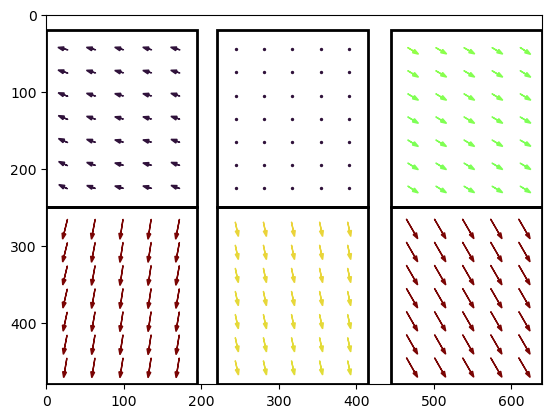

: 

: 

: 

: 

In [ ]:
# Intrinsic Calibration Figure

plt.figure()
ax = plt.gca()
ax.set_xlim(0, image_shape[1])
ax.set_ylim(0, image_shape[0])

cmap = matplotlib.cm.turbo

minv = 0

for cam_num, indices in calib_manager.crop_indices.items():
    corner = (indices[2], indices[0])
    width = indices[3] - indices[2]
    height = indices[1] - indices[0]

    rect = Rectangle(corner, width, height, fill=None, linewidth=2)
    ax.add_artist(rect)

    spacing = 25
    x_locs = np.linspace(
        spacing, height - spacing, int((height - 2 * spacing) / spacing)
    )
    y_locs = np.linspace(spacing, width - spacing, int((width - 2 * spacing) / spacing))

    # for i, j in np.ndindex((len(x_locs), len(y_locs))):
    #    x = x_locs[i]
    #    y = y_locs[j]
    y_coords, x_coords = np.meshgrid(y_locs, x_locs)
    y_coords = y_coords.flatten()
    x_coords = x_coords.flatten()
    all_v0, all_v1 = system.get_pixel_shifts(cam_num, x_coords, y_coords)

    for x, y, v0, v1 in zip(x_coords, y_coords, all_v0, all_v1):
        startx = x - v0 / 2 + indices[0]
        starty = y - v1 / 2 + indices[2]

        norm = np.sqrt(v0**2 + v1**2)
        norm = (norm - minv) / (maxv - minv)
        color = cmap(norm)
        if cam_num != calib_manager.reference_camera:
            plt.arrow(starty, startx, v1, v0, head_width=5, color=color)

    norms = np.sqrt(all_v0**2 + all_v1**2)
    maxv = max(np.max(norms), maxv)
    # minv = min(np.min(norms), minv)

    if cam_num == calib_manager.reference_camera:
        x_coords = x_coords + indices[0]
        y_coords = y_coords + indices[2]
        plt.scatter(y_coords, x_coords, color=cmap(0), s=2)
    # break


# ax.set_xticks([])
# ax.set_yticks([])

ax.invert_yaxis()

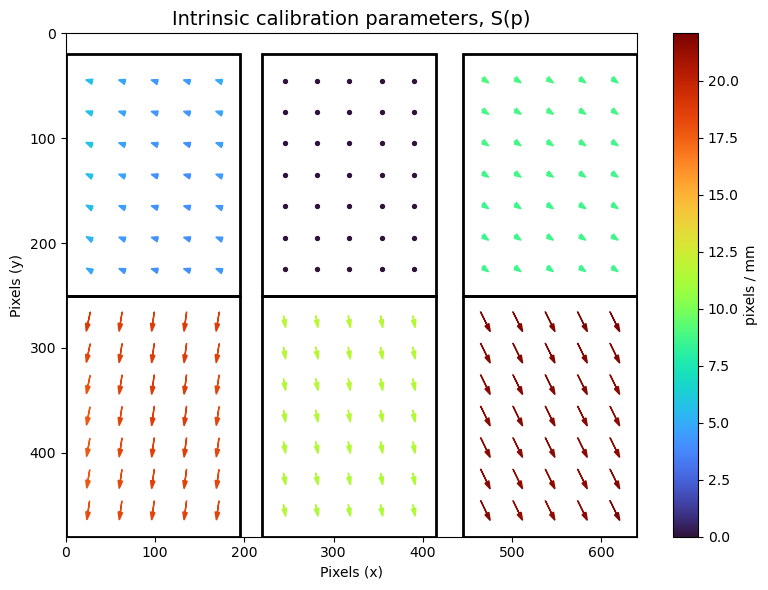

: 

: 

: 

: 

In [ ]:
# Intrinsic Calibration Figure

plt.figure(figsize=(8,6))
ax = plt.gca()

ax.set_xlim(0, image_shape[1])
ax.set_ylim(0, image_shape[0])

cmap = matplotlib.cm.turbo

# ---------------------------------------------------
# First pass: compute magnitude range for color scale
# ---------------------------------------------------

all_norms = []

for cam_num, indices in calib_manager.crop_indices.items():

    spacing = 25
    height = indices[1] - indices[0]
    width = indices[3] - indices[2]

    x_locs = np.linspace(spacing, height - spacing, int((height - 2 * spacing) / spacing))
    y_locs = np.linspace(spacing, width - spacing, int((width - 2 * spacing) / spacing))

    y_coords, x_coords = np.meshgrid(y_locs, x_locs)
    y_coords = y_coords.flatten()
    x_coords = x_coords.flatten()

    all_v0, all_v1 = system.get_pixel_shifts(cam_num, x_coords, y_coords)

    norms = np.sqrt(all_v0**2 + all_v1**2)
    all_norms.extend(norms)

minv = np.min(all_norms)
maxv = np.max(all_norms)

# ---------------------------------------------------
# Second pass: plot vectors
# ---------------------------------------------------

for cam_num, indices in calib_manager.crop_indices.items():

    corner = (indices[2], indices[0])
    width = indices[3] - indices[2]
    height = indices[1] - indices[0]

    rect = Rectangle(corner, width, height, fill=None, linewidth=2)
    ax.add_artist(rect)

    spacing = 25

    x_locs = np.linspace(spacing, height - spacing, int((height - 2 * spacing) / spacing))
    y_locs = np.linspace(spacing, width - spacing, int((width - 2 * spacing) / spacing))

    y_coords, x_coords = np.meshgrid(y_locs, x_locs)
    y_coords = y_coords.flatten()
    x_coords = x_coords.flatten()

    all_v0, all_v1 = system.get_pixel_shifts(cam_num, x_coords, y_coords)

    for x, y, v0, v1 in zip(x_coords, y_coords, all_v0, all_v1):

        startx = x - v0/2 + indices[0]
        starty = y - v1/2 + indices[2]

        norm = np.sqrt(v0**2 + v1**2)
        norm = (norm - minv) / (maxv - minv)

        color = cmap(norm)

        if cam_num != calib_manager.reference_camera:
            ax.arrow(starty, startx, v1, v0,
                     head_width=5,
                     length_includes_head=True,
                     color=color)

    # Reference camera plotted as points
    if cam_num == calib_manager.reference_camera:
        x_coords = x_coords + indices[0]
        y_coords = y_coords + indices[2]
        ax.scatter(y_coords, x_coords, color=cmap(0), s=8)

# ---------------------------------------------------
# Labels and formatting
# ---------------------------------------------------

ax.set_title("Intrinsic calibration parameters, S(p)", fontsize=14)

ax.set_xlabel("Pixels (x)")
ax.set_ylabel("Pixels (y)")

ax.invert_yaxis()

# ---------------------------------------------------
# Colorbar
# ---------------------------------------------------

sm = plt.cm.ScalarMappable(cmap=cmap,
                           norm=matplotlib.colors.Normalize(vmin=minv, vmax=maxv))
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("pixels / mm")

plt.tight_layout()
plt.show()

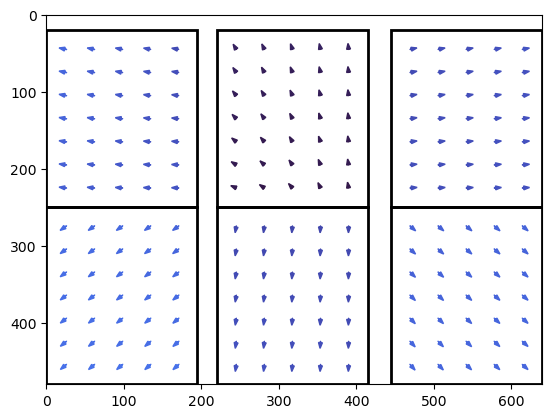

: 

: 

: 

: 

In [ ]:
# Extrinsic Calibration Figure

plt.figure()
ax = plt.gca()
ax.set_xlim(0, image_shape[1])
ax.set_ylim(0, image_shape[0])

cmap = matplotlib.cm.turbo

minv = 0

for cam_num, indices in calib_manager.crop_indices.items():
    corner = (indices[2], indices[0])
    width = indices[3] - indices[2]
    height = indices[1] - indices[0]

    rect = Rectangle(corner, width, height, fill=None, linewidth=2)
    ax.add_artist(rect)

    spacing = 25
    x_locs = np.linspace(
        spacing, height - spacing, int((height - 2 * spacing) / spacing)
    )
    y_locs = np.linspace(spacing, width - spacing, int((width - 2 * spacing) / spacing))

    # for i, j in np.ndindex((len(x_locs), len(y_locs))):
    #    x = x_locs[i]
    #    y = y_locs[j]
    y_coords, x_coords = np.meshgrid(y_locs, x_locs)
    y_coords = y_coords.flatten()
    x_coords = x_coords.flatten()
    all_v0, all_v1 = system.get_shift_slopes(cam_num, x_coords, y_coords)

    for x, y, v0, v1 in zip(x_coords, y_coords, all_v0, all_v1):
        startx = x - v0 / 2 + indices[0]
        starty = y - v1 / 2 + indices[2]

        norm = np.sqrt(v0**2 + v1**2)
        norm = (norm - minv) / (maxv - minv)
        color = cmap(norm)
        # if cam_num != calib_manager.reference_camera:
        plt.arrow(starty, startx, v1, v0, head_width=5, color=color)

    norms = np.sqrt(all_v0**2 + all_v1**2)
    maxv = max(np.max(norms), maxv)

ax.invert_yaxis()

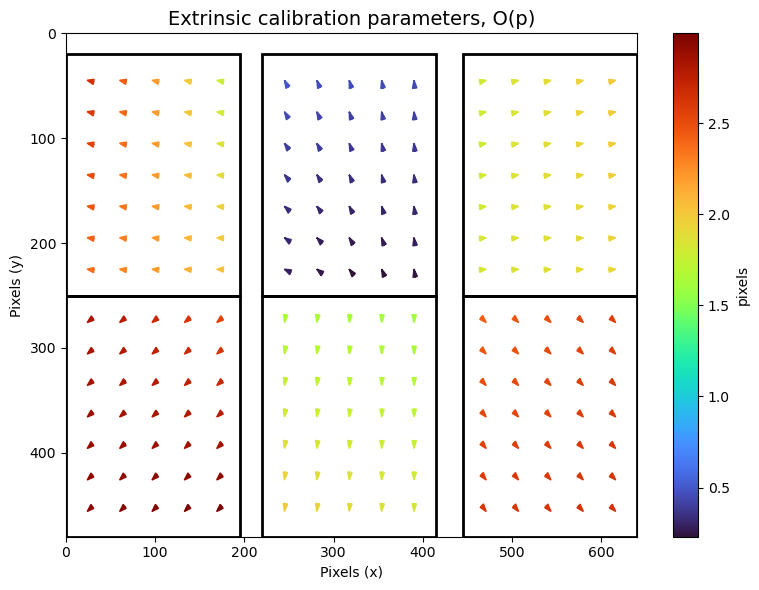

: 

: 

: 

: 

: 

In [ ]:
# Extrinsic Calibration Figure

plt.figure(figsize=(8,6))
ax = plt.gca()

ax.set_xlim(0, image_shape[1])
ax.set_ylim(0, image_shape[0])

cmap = matplotlib.cm.turbo

# ---------------------------------------------------
# First pass: compute magnitude range
# ---------------------------------------------------

all_norms = []

for cam_num, indices in calib_manager.crop_indices.items():

    spacing = 25
    height = indices[1] - indices[0]
    width = indices[3] - indices[2]

    x_locs = np.linspace(spacing, height - spacing,
                         int((height - 2 * spacing) / spacing))
    y_locs = np.linspace(spacing, width - spacing,
                         int((width - 2 * spacing) / spacing))

    y_coords, x_coords = np.meshgrid(y_locs, x_locs)
    y_coords = y_coords.flatten()
    x_coords = x_coords.flatten()

    all_v0, all_v1 = system.get_shift_slopes(cam_num, x_coords, y_coords)

    norms = np.sqrt(all_v0**2 + all_v1**2)
    all_norms.extend(norms)

minv = np.min(all_norms)
maxv = np.max(all_norms)

# ---------------------------------------------------
# Second pass: draw vectors
# ---------------------------------------------------

for cam_num, indices in calib_manager.crop_indices.items():

    corner = (indices[2], indices[0])
    width = indices[3] - indices[2]
    height = indices[1] - indices[0]

    rect = Rectangle(corner, width, height, fill=None, linewidth=2)
    ax.add_artist(rect)

    spacing = 25

    x_locs = np.linspace(spacing, height - spacing,
                         int((height - 2 * spacing) / spacing))
    y_locs = np.linspace(spacing, width - spacing,
                         int((width - 2 * spacing) / spacing))

    y_coords, x_coords = np.meshgrid(y_locs, x_locs)
    y_coords = y_coords.flatten()
    x_coords = x_coords.flatten()

    all_v0, all_v1 = system.get_shift_slopes(cam_num, x_coords, y_coords)

    for x, y, v0, v1 in zip(x_coords, y_coords, all_v0, all_v1):

        startx = x - v0/2 + indices[0]
        starty = y - v1/2 + indices[2]

        norm = np.sqrt(v0**2 + v1**2)
        norm = (norm - minv) / (maxv - minv)

        color = cmap(norm)

        ax.arrow(starty, startx, v1, v0,
                 head_width=5,
                 length_includes_head=True,
                 color=color)

# ---------------------------------------------------
# Formatting
# ---------------------------------------------------

ax.set_title("Extrinsic calibration parameters, O(p)", fontsize=14)

ax.set_xlabel("Pixels (x)")
ax.set_ylabel("Pixels (y)")

ax.invert_yaxis()

# ---------------------------------------------------
# Colorbar
# ---------------------------------------------------

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=matplotlib.colors.Normalize(vmin=minv, vmax=maxv)
)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("pixels")

plt.tight_layout()
plt.show()

: 

: 

: 

: 